# CTR Prediction

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [6]:
train["label"].value_counts(normalize=True)

label
0    0.968
1    0.032
Name: proportion, dtype: float64

40000 rows in train dataset
10000 rows in test dataset

Since there are only 1280 clicks against 38720 no clicks in train dataset, even if a model predicts 0 for everything it will have 96.8% accuracy. Thats why we use other metrics such as Precision, Recall, F1, ROC-AUC

In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["label"] #makes sure proportionate clicks and no clicks are split in train and validation
)

In [8]:
num_cols = [col for col in train.columns if col.startswith("integer_feature")]
cat_cols = [col for col in train.columns if col.startswith("categorical_feature")]

#splitting numerical feature columns and categorical ones
X_train_num = train_df[num_cols]
X_val_num = val_df[num_cols]

X_train_cat = train_df[cat_cols]
X_val_cat = val_df[cat_cols]

y_train = train_df["label"]
y_val = val_df["label"]

### Numerical Features
As numerical features have a wide range of values, they should be normalised using $$ x' = \frac{x - \mu}{\sigma} $$


In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#replace NaN values with median of training set so that it is less affected by outliers
num_imputer = SimpleImputer(strategy="median")

X_train_num = num_imputer.fit_transform(X_train_num)
X_val_num = num_imputer.transform(X_val_num)

#now we standardise using the above formula
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_val_num = scaler.transform(X_val_num) #not fit_transform bcoz val data should not leak into model

### Categorical Features
We create mappings for each category to represent them using integers


In [10]:
X_train_cat = X_train_cat.fillna("UNKNOWN")
X_val_cat = X_val_cat.fillna("UNKNOWN")

cat_maps = {}
cat_cardinalities = {}

for col in cat_cols:
    categories = X_train_cat[col].unique()

    # 0 will represent UNKNOWN
    mapping = {cat: i + 1 for i, cat in enumerate(categories)}

    cat_maps[col] = mapping
    cat_cardinalities[col] = len(mapping) + 1 #reserve one more category for category which might appear in val/test but not present in train

for col in cat_cols:
    X_train_cat[col] = X_train_cat[col].map(cat_maps[col]).fillna(0).astype(int)
    X_val_cat[col] = X_val_cat[col].map(cat_maps[col]).fillna(0).astype(int)

In [11]:
#converting to torch tensors to work in pytorch

X_train_num = torch.tensor(X_train_num, dtype=torch.float32)
X_val_num = torch.tensor(X_val_num, dtype=torch.float32)

X_train_cat = torch.tensor(X_train_cat.values, dtype=torch.long)
X_val_cat = torch.tensor(X_val_cat.values, dtype=torch.long)

In [12]:
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)

In [13]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train_num,
    X_train_cat,
    y_train
)

val_dataset = TensorDataset(
    X_val_num,
    X_val_cat,
    y_val
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 32000
Validation samples: 8000


Now we need to group data into batches and for that we use DataLoader

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False #no learning happening during validation
)

For categorical features we cant just use integers to represent categories as that will assume relationships between categories, we avoid one hot encoding as features are higher

Embedding into learnable vectors and finding values by training is better

In [15]:
import torch.nn as nn

embedding_dim = 8 #number of embedding values each category will have
#example mobile = [0.21, -0.42, 0.73, 0.15, 0.32, 0.28, -0.7, 0.98]

embeddings = nn.ModuleList([
    nn.Embedding(cardinality, embedding_dim)
    for cardinality in cat_cardinalities.values()
])

print("Number of embedding layers:", len(embeddings))

Number of embedding layers: 26


Now each batch has 256 rows where each row represents data in combined form of categorical features (26*8)=208 and numerical features(13) 

In [26]:
class CTRModel(nn.Module):
    def __init__(self, num_features, cat_cardinalities, embedding_dim=8):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, embedding_dim)
            for cardinality in cat_cardinalities
        ])

        input_dim = num_features + len(cat_cardinalities) * embedding_dim

        #Multi Layer Perceptron
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        #we do not add sigmoid as we will use BCEWithLogitLoss() which is sigmoid + BCE Loss

    def forward(self, x_num, x_cat):
        embedded = [
            embedding(x_cat[:, i])
            for i, embedding in enumerate(self.embeddings)
        ]

        x_cat = torch.cat(embedded, dim=1) #concatenate all embeddings of categorical features
        x = torch.cat([x_num, x_cat], dim=1) #concatenate categorical and numerical features

        return self.mlp(x).squeeze(1)


model = CTRModel(
    num_features=len(num_cols),
    cat_cardinalities=list(cat_cardinalities.values()),
    embedding_dim=8
)

print(model)

CTRModel(
  (embeddings): ModuleList(
    (0): Embedding(10858, 8)
    (1): Embedding(3349, 8)
    (2): Embedding(4586, 8)
    (3): Embedding(1614, 8)
    (4): Embedding(3643, 8)
    (5): Embedding(4, 8)
    (6): Embedding(2912, 8)
    (7): Embedding(711, 8)
    (8): Embedding(23, 8)
    (9): Embedding(9625, 8)
    (10): Embedding(4772, 8)
    (11): Embedding(6821, 8)
    (12): Embedding(10, 8)
    (13): Embedding(821, 8)
    (14): Embedding(1833, 8)
    (15): Embedding(43, 8)
    (16): Embedding(5, 8)
    (17): Embedding(310, 8)
    (18): Embedding(15, 8)
    (19): Embedding(11112, 8)
    (20): Embedding(7581, 8)
    (21): Embedding(10423, 8)
    (22): Embedding(4362, 8)
    (23): Embedding(3258, 8)
    (24): Embedding(36, 8)
    (25): Embedding(25, 8)
  )
  (mlp): Sequential(
    (0): Linear(in_features=221, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=Tru

**Loss Function** : Binary Cross Entropy because we have two prediction outputs -> 0 for no click and 1 for click
$$
L = -\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$
**Optimizer** : We use Adam over SGD because SGD uses gradient descent to convert weights and bias but Adam adapts learning rate for each parameter and hence it is a good pick for neural networks

In [28]:
import torch
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []
val_losses = []

for epoch in range(epochs):
    #Training Loop
    model.train()
    training_loss = 0.0

    for num_batch, cat_batch, label_batch in train_loader:
        #Forward Pass -> Loss -> Backpropagation -> Update weights
        logits = model(num_batch, cat_batch)
        loss = criterion(logits, label_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        training_loss += loss.item()

    training_loss /= len(train_loader)
    train_losses.append(training_loss)

    #Validation Loop
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for num_batch, cat_batch, label_batch in val_loader:
            logits = model(num_batch, cat_batch)
            loss = criterion(logits, label_batch)

            val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)


    print(
        f"Epoch {epoch+1}/{epochs} | ",
        f"Training Loss : {training_loss:.4f} | "
        f"Validation Loss : {val_loss:.4f}"
    )


Epoch 1/10 |  Training Loss : 0.0954 | Validation Loss : 0.1576
Epoch 2/10 |  Training Loss : 0.0800 | Validation Loss : 0.1814
Epoch 3/10 |  Training Loss : 0.0627 | Validation Loss : 0.2023
Epoch 4/10 |  Training Loss : 0.0470 | Validation Loss : 0.2506
Epoch 5/10 |  Training Loss : 0.0361 | Validation Loss : 0.2835
Epoch 6/10 |  Training Loss : 0.0270 | Validation Loss : 0.3200
Epoch 7/10 |  Training Loss : 0.0214 | Validation Loss : 0.3568
Epoch 8/10 |  Training Loss : 0.0169 | Validation Loss : 0.3954
Epoch 9/10 |  Training Loss : 0.0153 | Validation Loss : 0.4173
Epoch 10/10 |  Training Loss : 0.0099 | Validation Loss : 0.4601


The model is overfitting heavily as training loss decreases significantly while validation loss increases

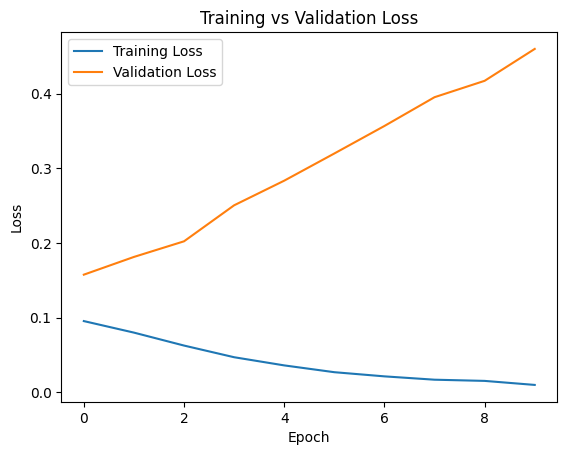

In [29]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [30]:
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for num_batch, cat_batch, label_batch in val_loader:

        logits = model(num_batch, cat_batch)

        # Convert logits → probabilities
        probs = torch.sigmoid(logits)

        val_probs.extend(probs.numpy())
        val_labels.extend(label_batch.numpy())

print("Number of predictions:", len(val_probs))
print("First 10 probabilities:", val_probs[:10])
print("First 10 actual labels:", val_labels[:10])

Number of predictions: 8000
First 10 probabilities: [np.float32(7.678061e-06), np.float32(0.0012373339), np.float32(2.3072931e-05), np.float32(3.285487e-10), np.float32(1.5445377e-08), np.float32(5.0414303e-07), np.float32(6.004864e-08), np.float32(0.017754585), np.float32(9.090127e-06), np.float32(3.7422132e-07)]
First 10 actual labels: [np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0), np.float32(0.0)]


Plotting ROC-AUC Curve and PR-AUC Curve  
These are important bcoz only 3.2% are clicks

In [31]:
from sklearn.metrics import log_loss

val_logloss = log_loss(val_labels, val_probs)

print(f"Validation Log Loss: {val_logloss:.4f}")

Validation Log Loss: 0.4656


In [64]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

threshold = 0.5

val_preds = [
    1 if prob >= threshold else 0
    for prob in val_probs
]

f1 = f1_score(val_labels, val_preds)
precision = precision_score(val_labels, val_preds)
recall = recall_score(val_labels, val_preds)

roc_auc = roc_auc_score(val_labels, val_probs)
pr_auc = average_precision_score(val_labels, val_probs)

print(f"Threshold: {threshold}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Threshold: 0.5
ROC-AUC:   0.5804
PR-AUC:    0.0487
F1:        0.0680
Precision: 0.0897
Recall:    0.0547


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 1.0, 0.05) #trying out different thresholds

f1_scores = []

for threshold in thresholds:
    preds = (np.array(val_probs) >= threshold).astype(int)
    f1_scores.append(f1_score(val_labels, preds))

for threshold, f1 in zip(thresholds, f1_scores):
    print(f"Threshold: {threshold:.2f} | F1: {f1:.4f}")

Threshold: 0.10 | F1: 0.0792
Threshold: 0.15 | F1: 0.0773
Threshold: 0.20 | F1: 0.0760
Threshold: 0.25 | F1: 0.0816
Threshold: 0.30 | F1: 0.0761
Threshold: 0.35 | F1: 0.0702
Threshold: 0.40 | F1: 0.0729
Threshold: 0.45 | F1: 0.0704
Threshold: 0.50 | F1: 0.0680
Threshold: 0.55 | F1: 0.0657
Threshold: 0.60 | F1: 0.0672
Threshold: 0.65 | F1: 0.0638
Threshold: 0.70 | F1: 0.0663
Threshold: 0.75 | F1: 0.0634
Threshold: 0.80 | F1: 0.0536
Threshold: 0.85 | F1: 0.0486
Threshold: 0.90 | F1: 0.0376
Threshold: 0.95 | F1: 0.0267


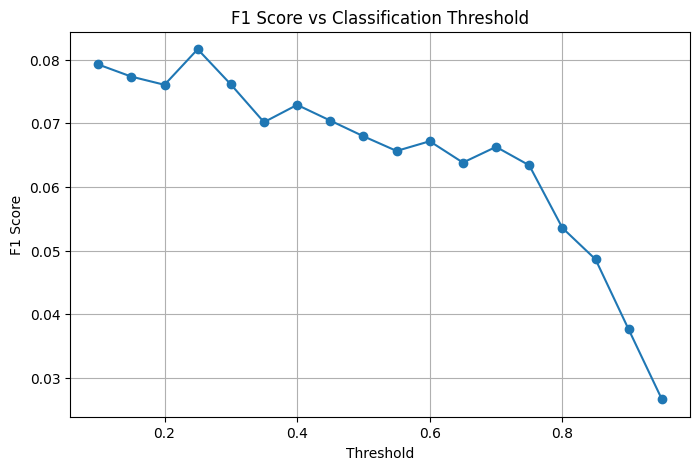

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_scores, marker="o")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.grid(True)
plt.show()

Hence we'll pick threshold as 0.25

In [65]:
best_f1 = 0.0816

Trying another architecture with reduced capacity as more capacity means model can learn more complex relationships but also tends to overfit more, so reducing capacity will ensure simpler model and reduce overfitting

In [47]:
import torch.nn as nn

class CTRModel2(nn.Module):
    def __init__(self, num_features, cat_cardinalities, embedding_dim=8):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, embedding_dim)
            for cardinality in cat_cardinalities
        ])

        input_dim = num_features + len(cat_cardinalities) * embedding_dim

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_num, x_cat):
        embedded = [
            embedding(x_cat[:, i])
            for i, embedding in enumerate(self.embeddings)
        ]

        x_cat = torch.cat(embedded, dim=1)
        x = torch.cat([x_num, x_cat], dim=1)

        return self.mlp(x).squeeze(1)


model = CTRModel2(
    num_features=len(num_cols),
    cat_cardinalities=list(cat_cardinalities.values()),
    embedding_dim=8
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [48]:
num_epochs = 5

train_losses_2= []
val_losses_2 = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for num_batch, cat_batch, label_batch in train_loader:
        logits = model(num_batch, cat_batch)
        loss = criterion(logits, label_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses_2.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for num_batch, cat_batch, label_batch in val_loader:
            logits = model(num_batch, cat_batch)
            loss = criterion(logits, label_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses_2.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Training Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

Epoch 1/5 | Training Loss: 0.1812 | Validation Loss: 0.1351
Epoch 2/5 | Training Loss: 0.1363 | Validation Loss: 0.1328
Epoch 3/5 | Training Loss: 0.1318 | Validation Loss: 0.1332
Epoch 4/5 | Training Loss: 0.1266 | Validation Loss: 0.1351
Epoch 5/5 | Training Loss: 0.1204 | Validation Loss: 0.1367


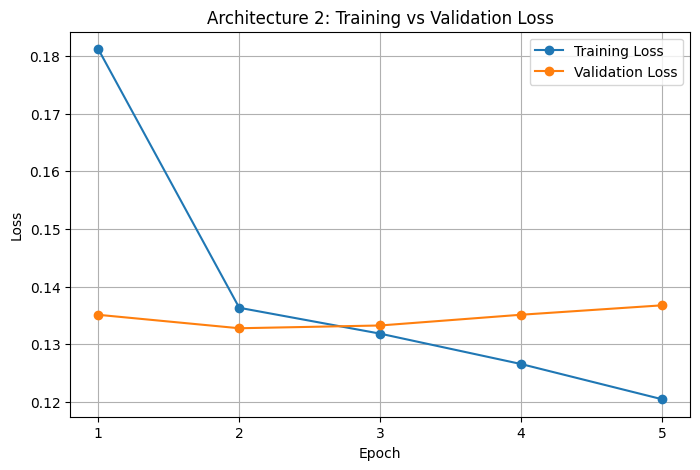

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses_2) + 1),
    train_losses_2,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, len(val_losses_2) + 1),
    val_losses_2,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Architecture 2: Training vs Validation Loss")
plt.xticks(range(1, len(train_losses_2) + 1))
plt.legend()
plt.grid(True)
plt.show()

Better but it will start overfitting after more epochs

Introducing a middle ground and using Dropout will make memorization harder for the next architecture

In [57]:
import torch.nn as nn

class CTRModel3(nn.Module):
    def __init__(self, num_features, cat_cardinalities, embedding_dim=8):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, embedding_dim)
            for cardinality in cat_cardinalities
        ])

        input_dim = num_features + len(cat_cardinalities) * embedding_dim

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x_num, x_cat):
        embedded = [
            embedding(x_cat[:, i])
            for i, embedding in enumerate(self.embeddings)
        ]

        x_cat = torch.cat(embedded, dim=1)
        x = torch.cat([x_num, x_cat], dim=1)

        return self.mlp(x).squeeze(1)


model = CTRModel3(
    num_features=len(num_cols),
    cat_cardinalities=list(cat_cardinalities.values()),
    embedding_dim=8
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [58]:
num_epochs = 3

train_losses_3 = []
val_losses_3 = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0

    for num_batch, cat_batch, label_batch in train_loader:
        logits = model(num_batch, cat_batch)
        loss = criterion(logits, label_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses_3.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for num_batch, cat_batch, label_batch in val_loader:
            logits = model(num_batch, cat_batch)
            loss = criterion(logits, label_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses_3.append(val_loss)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Training Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

Epoch  1/3 | Training Loss: 0.2115 | Validation Loss: 0.1335
Epoch  2/3 | Training Loss: 0.1382 | Validation Loss: 0.1305
Epoch  3/3 | Training Loss: 0.1314 | Validation Loss: 0.1303


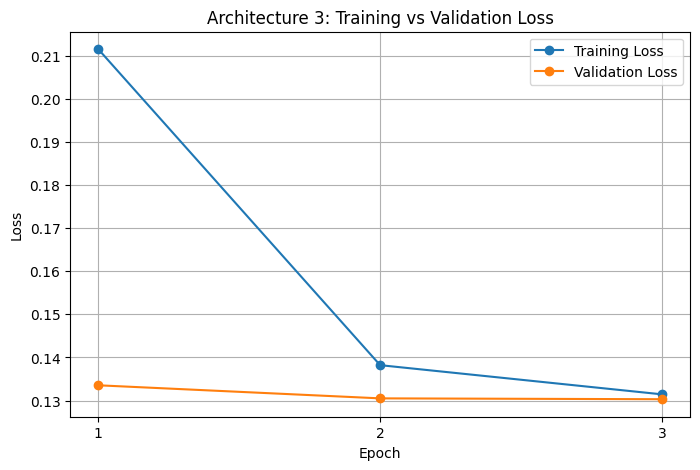

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses_3) + 1),
    train_losses_3,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, len(val_losses_3) + 1),
    val_losses_3,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Architecture 3: Training vs Validation Loss")
plt.xticks(range(1, len(train_losses_3) + 1))
plt.legend()
plt.grid(True)
plt.show()

Lets choose 3rd epoch model as it gives best val loss before shooting off

In [60]:
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

model.eval()

val_probs_better = []
val_labels_better = []

with torch.no_grad():
    for num_batch, cat_batch, label_batch in val_loader:
        logits = model(num_batch, cat_batch)
        probs = torch.sigmoid(logits)

        val_probs_better.extend(probs.numpy())
        val_labels_better.extend(label_batch.numpy())

roc_auc_better = roc_auc_score(
    val_labels_better,
    val_probs_better
)

pr_auc_better = average_precision_score(
    val_labels_better,
    val_probs_better
)

logloss_better = log_loss(
    val_labels_better,
    val_probs_better
)

print("Architecture 3")
print(f"ROC-AUC: {roc_auc_better:.4f}")
print(f"PR-AUC:  {pr_auc_better:.4f}")
print(f"Log Loss: {logloss_better:.4f}")

Architecture 3
ROC-AUC: 0.7075
PR-AUC:  0.0869
Log Loss: 0.1325


In [62]:
import numpy as np
from sklearn.metrics import f1_score

thresholds_better = np.arange(0.01, 1.00, 0.01)

f1_scores_better = []

for threshold in thresholds_better:
    preds = (np.array(val_probs_better) >= threshold).astype(int)
    f1_scores_better.append(
        f1_score(val_labels_better, preds)
    )

best_idx_better = np.argmax(f1_scores_better)

best_threshold_better = thresholds_better[best_idx_better]
best_f1_better = f1_scores_better[best_idx_better]

print(f"Best Threshold: {best_threshold_better:.2f}")
print(f"Best F1:        {best_f1_better:.4f}")
print(f"ROC-AUC:        {roc_auc_better:.4f}")
print(f"PR-AUC:         {pr_auc_better:.4f}")

Best Threshold: 0.08
Best F1:        0.1491
ROC-AUC:        0.7075
PR-AUC:         0.0869


In [67]:
import pandas as pd

comparison = pd.DataFrame({
    "Architecture": [
        "Architecture 1",
        "Architecture 3"
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_better
    ],
    "PR-AUC": [
        pr_auc,
        pr_auc_better
    ],
    "F1": [
        best_f1,
        best_f1_better
    ]
})

print(comparison.round(4))

     Architecture  ROC-AUC  PR-AUC      F1
0  Architecture 1   0.5804  0.0487  0.0816
1  Architecture 3   0.7075  0.0869  0.1491


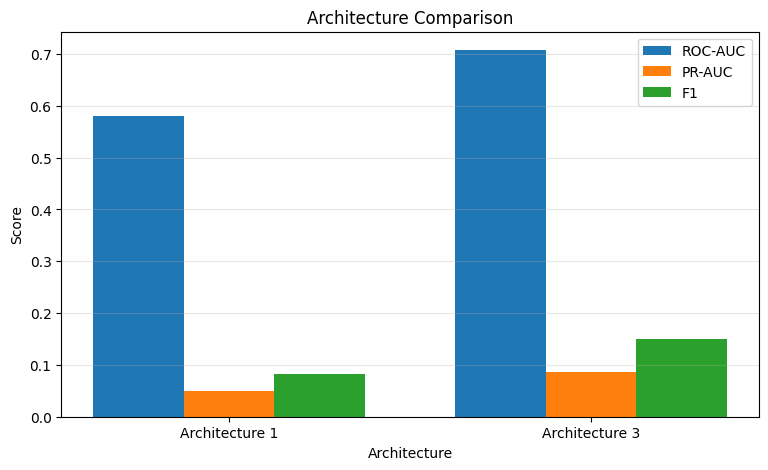

In [68]:
import matplotlib.pyplot as plt
import numpy as np

architectures = ["Architecture 1", "Architecture 3"]

roc_auc_values = [0.5804, 0.7075]
pr_auc_values = [0.0487, 0.0869]
f1_values = [0.0816, 0.1491]

x = np.arange(len(architectures))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - width, roc_auc_values, width, label="ROC-AUC")
plt.bar(x, pr_auc_values, width, label="PR-AUC")
plt.bar(x + width, f1_values, width, label="F1")

plt.xlabel("Architecture")
plt.ylabel("Score")
plt.title("Architecture Comparison")
plt.xticks(x, architectures)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

3rd architecture is better performing

### Testing

In [70]:
X_test_num = test[num_cols].copy()

# Use the imputer fitted on training data
X_test_num = num_imputer.transform(X_test_num)

# Use the scaler fitted on training data
X_test_num = scaler.transform(X_test_num)

X_test_cat = test[cat_cols].copy()

# Handle missing categorical values
X_test_cat = X_test_cat.fillna("UNKNOWN")

# Use the mappings learned from training data
for col in cat_cols:
    X_test_cat[col] = (
        X_test_cat[col]
        .map(cat_maps[col])
        .fillna(0)
        .astype(int)
    )

X_test_num = torch.tensor(
    X_test_num,
    dtype=torch.float32
)

X_test_cat = torch.tensor(
    X_test_cat.to_numpy(),
    dtype=torch.long
)

y_test = torch.tensor(
    test["label"].to_numpy(),
    dtype=torch.float32
)

In [71]:
from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(
    X_test_num,
    X_test_cat,
    y_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

In [72]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score
)
import numpy as np

model.eval()

test_probs = []
test_labels = []

with torch.no_grad():
    for num_batch, cat_batch, label_batch in test_loader:
        logits = model(num_batch, cat_batch)
        probs = torch.sigmoid(logits)

        test_probs.extend(probs.numpy())
        test_labels.extend(label_batch.numpy())

# ROC-AUC and PR-AUC use probability scores
test_roc_auc = roc_auc_score(test_labels, test_probs)
test_pr_auc = average_precision_score(test_labels, test_probs)

# Use the threshold selected from validation
test_preds = (
    np.array(test_probs) >= best_threshold_better
).astype(int)

test_f1 = f1_score(test_labels, test_preds)

print("Final Test Results")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC:  {test_pr_auc:.4f}")
print(f"F1:      {test_f1:.4f}")
print(f"Threshold used: {best_threshold_better:.2f}")

Final Test Results
ROC-AUC: 0.6826
PR-AUC:  0.0687
F1:      0.1172
Threshold used: 0.08
